# Gridlock Hackathon - Step 1 EDA
This notebook runs the Step 1 EDA outputs and saves them to disk.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("dataset")
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [2]:
# Preserve raw copies for later feature interactions and submission
train_raw = train.copy()
test_raw = test.copy()

=== TRAIN ===
shape
(77299, 11)
dtypes
Index              int64
geohash              str
day                int64
timestamp            str
demand           float64
RoadType             str
NumberofLanes      int64
LargeVehicles        str
Landmarks            str
Temperature      float64
Weather              str
nulls
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
=== TEST ===
shape
(41778, 10)
dtypes
Index              int64
geohash              str
day                int64
timestamp            str
RoadType             str
NumberofLanes      int64
LargeVehicles        str
Landmarks            str
Temperature      float64
Weather              str
nulls
Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicle

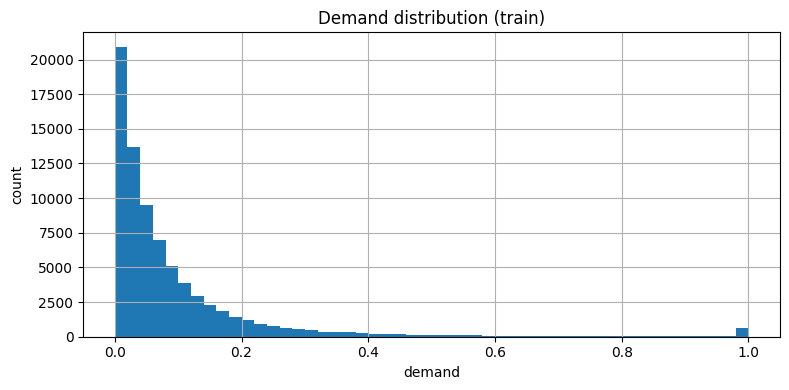

Histogram saved to: eda_outputs\demand_hist.png
=== UNIQUE VALUE COUNTS (train) ===
value_counts: day
day
48    69427
49     7872
value_counts: RoadType
RoadType
Residential    69230
Street          3909
Highway         3560
NaN              600
value_counts: NumberofLanes
NumberofLanes
1    27411
2    24127
3    23919
4      926
5      916
value_counts: LargeVehicles
LargeVehicles
Not Allowed    50673
Allowed        26626
value_counts: Landmarks
Landmarks
Yes    52042
No     25257
value_counts: Weather
Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
NaN        797
=== GEOHASH SAMPLE + LENGTHS (train) ===
geohash head(10)
0    qp02z1
1    qp02zt
2    qp08bj
3    qp08gt
4    qp02zq
5    qp02zw
6    qp02zy
7    qp08by
8    qp08gq
9    qp08gy
geohash length counts
geohash
6    77299
=== GROUPBY MEANS (train) ===
mean demand by day
day
48    0.092659
49    0.105262
mean demand by Weather
Weather
Foggy    0.093372
Rainy    0.094471
Snowy    0.092581
Sunny    0.094247
EDA

In [2]:
# Step 1 EDA outputs
output_dir = Path("eda_outputs")
output_dir.mkdir(exist_ok=True)
eda_log = []

def log(text):
    print(text)
    eda_log.append(str(text))

def log_block(obj, header=None):
    if header:
        log(header)
    if isinstance(obj, (pd.DataFrame, pd.Series)):
        text = obj.to_string()
    else:
        text = str(obj)
    print(text)
    eda_log.append(text)

# 1. shape, dtypes, nulls for train and test
for name, df in [("train", train), ("test", test)]:
    log(f"=== {name.upper()} ===")
    log_block(df.shape, "shape")
    log_block(df.dtypes, "dtypes")
    log_block(df.isnull().sum(), "nulls")

# 2. demand stats + skew + histogram
log("=== DEMAND STATS (train) ===")
log_block(train["demand"].describe(), "describe")
log_block(train["demand"].skew(), "skew")

plt.figure(figsize=(8, 4))
train["demand"].hist(bins=50)
plt.title("Demand distribution (train)")
plt.xlabel("demand")
plt.ylabel("count")
hist_path = output_dir / "demand_hist.png"
plt.tight_layout()
plt.savefig(hist_path, dpi=150)
plt.show()
log(f"Histogram saved to: {hist_path}")

# 3. Unique value counts
log("=== UNIQUE VALUE COUNTS (train) ===")
for col in ["day", "RoadType", "NumberofLanes", "LargeVehicles", "Landmarks", "Weather"]:
    log_block(train[col].value_counts(dropna=False), f"value_counts: {col}")

# 4. Sample geohash rows + string length
log("=== GEOHASH SAMPLE + LENGTHS (train) ===")
gh_sample = train["geohash"].head(10)
log_block(gh_sample, "geohash head(10)")
gh_len = train["geohash"].astype(str).str.len()
log_block(gh_len.value_counts(dropna=False).sort_index(), "geohash length counts")

# 5. Groupby means
log("=== GROUPBY MEANS (train) ===")
log_block(train.groupby("day")["demand"].mean(), "mean demand by day")
log_block(train.groupby("Weather")["demand"].mean(), "mean demand by Weather")

# 6. Save all EDA outputs
eda_path = output_dir / "eda_step1.txt"
eda_path.write_text("\n\n".join(eda_log), encoding="utf-8")
log(f"EDA outputs saved to: {eda_path}")

## Step 2 - Preprocessing Architecture
- Parse `timestamp` into `hour` and `minute` based on the dataset format (e.g., `0:0`, `2:15`).
- Use `day % 7` for cyclic features and weekend flags since `day` is sequential (e.g., 48, 49).
- Decode `geohash` into `lat`/`lng` with `pygeohash`; if decoding fails, leave `lat`/`lng` as NaN.
- Create geohash prefixes (`gh4`, `gh5`) and interaction feature `geohash_hour`.
- Convert `LargeVehicles` and `Landmarks` to binary numeric features.
- Fill numeric nulls with train medians and categorical nulls with train modes.
- Check demand skew to decide whether to apply `log1p`.

In [3]:
# Step 2 preprocessing
import numpy as np
import pandas as pd

# Ensure timestamp parsing is robust for H:M format
for df in [train, test]:
    time_parts = df["timestamp"].astype(str).str.split(":", n=1, expand=True)
    df["hour"] = time_parts[0].astype(int)
    df["minute"] = time_parts[1].astype(int)

# Cyclic features for hour and day-of-week (day is sequential, so use mod 7)
for df in [train, test]:
    day_mod = df["day"] % 7
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["day_sin"] = np.sin(2 * np.pi * day_mod / 7)
    df["day_cos"] = np.cos(2 * np.pi * day_mod / 7)
    df["is_peak_hour"] = df["hour"].isin([7, 8, 9, 17, 18, 19, 20]).astype(int)
    df["is_weekend"] = day_mod.isin([5, 6]).astype(int)

# Geohash decoding (lat/lng) with safe fallback
try:
    import pygeohash as pgh

    def safe_decode(gh):
        try:
            lat, lng = pgh.decode(gh)
            return pd.Series({"lat": lat, "lng": lng})
        except Exception:
            return pd.Series({"lat": np.nan, "lng": np.nan})

    for df in [train, test]:
        decoded = df["geohash"].astype(str).apply(safe_decode)
        df["lat"] = decoded["lat"].astype(float)
        df["lng"] = decoded["lng"].astype(float)
    geohash_decoded = True
except Exception as exc:
    geohash_decoded = False
    print(f"pygeohash decode failed: {exc}. lat/lng set to NaN.")
    for df in [train, test]:
        df["lat"] = np.nan
        df["lng"] = np.nan

# Geohash prefix and interaction features
for df in [train, test]:
    df["gh4"] = df["geohash"].astype(str).str[:4]
    df["gh5"] = df["geohash"].astype(str).str[:5]
    df["geohash_hour"] = df["geohash"].astype(str) + "_" + df["hour"].astype(str)

# Binary mapping for LargeVehicles and Landmarks
def map_binary(series, mapping):
    return series.astype(str).str.strip().str.lower().map(mapping)

for df in [train, test]:
    df["LargeVehicles"] = map_binary(df["LargeVehicles"], {"allowed": 1, "not allowed": 0})
    df["Landmarks"] = map_binary(df["Landmarks"], {"yes": 1, "no": 0})

# Handle nulls: numeric -> median (from train), categorical -> mode (from train)
train_numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
train_numeric_cols = [c for c in train_numeric_cols if c != "demand"]
train_cat_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_fill = train[train_numeric_cols].median()
cat_fill = train[train_cat_cols].mode(dropna=True).iloc[0]

train[train_numeric_cols] = train[train_numeric_cols].fillna(numeric_fill)
test[train_numeric_cols] = test[train_numeric_cols].fillna(numeric_fill)
train[train_cat_cols] = train[train_cat_cols].fillna(cat_fill)
test[train_cat_cols] = test[train_cat_cols].fillna(cat_fill)

# Demand skew check and optional log1p transform
y_train_original = train["demand"].copy()
demand_skew = y_train_original.skew()
use_log1p = demand_skew > 0.5

if use_log1p:
    y_train = np.log1p(y_train_original)
else:
    y_train = y_train_original.copy()

print(f"Geohash decoded: {geohash_decoded}")
print(f"Demand skew: {demand_skew:.4f} | log1p applied: {use_log1p}")
print("Nulls after fill (train/test):", train.isnull().sum().sum(), test.isnull().sum().sum())
print(train[["hour", "minute", "hour_sin", "hour_cos", "day", "day_sin", "day_cos", "is_peak_hour", "is_weekend", "lat", "lng", "gh4", "gh5", "geohash_hour", "LargeVehicles", "Landmarks"]].head())

Geohash decoded: True
Demand skew: 3.7285 | log1p applied: True
Nulls after fill (train/test): 0 0
   hour  minute  hour_sin  hour_cos  day   day_sin  day_cos  is_peak_hour  \
0     0       0       0.0       1.0   48 -0.781831  0.62349             0   
1     0       0       0.0       1.0   48 -0.781831  0.62349             0   
2     0       0       0.0       1.0   48 -0.781831  0.62349             0   
3     0       0       0.0       1.0   48 -0.781831  0.62349             0   
4     0       0       0.0       1.0   48 -0.781831  0.62349             0   

   is_weekend       lat        lng   gh4    gh5 geohash_hour  LargeVehicles  \
0           1 -5.484924  90.664673  qp02  qp02z     qp02z1_0              0   
1           1 -5.462952  90.686646  qp02  qp02z     qp02zt_0              1   
2           1 -5.462952  90.708618  qp08  qp08b     qp08bj_0              0   
3           1 -5.462952  90.862427  qp08  qp08g     qp08gt_0              0   
4           1 -5.457458  90.675659  qp02  q

## Step 3 - Encoding Architecture
- Use 5-fold out-of-fold target encoding to avoid leakage for: `geohash`, `gh4`, `gh5`, `geohash_hour`, `RoadType`, `Weather`.
- Fit the target-encoding mapping on each training fold and apply to its validation fold.
- Fit a full-train mapping for the test set.
- Label-encode any remaining categorical columns to numeric codes for downstream models.

In [4]:
# Step 3 encoding (5-fold target encoding + label encoding)
import numpy as np
import pandas as pd

try:
    from sklearn.model_selection import KFold
except Exception as exc:
    raise ImportError("scikit-learn is required for KFold. Please install scikit-learn.") from exc

def target_encode_cv(train_df, test_df, col, target_series, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    global_mean = target_series.mean()
    oof = pd.Series(index=train_df.index, dtype=float)

    for tr_idx, val_idx in kf.split(train_df):
        tr_fold = train_df.iloc[tr_idx]
        val_fold = train_df.iloc[val_idx]
        fold_target = target_series.iloc[tr_idx]
        mapping = fold_target.groupby(tr_fold[col]).mean()
        encoded = val_fold[col].map(mapping).fillna(global_mean)
        oof.iloc[val_idx] = encoded.values

    test_mapping = target_series.groupby(train_df[col]).mean()
    test_encoded = test_df[col].map(test_mapping).fillna(global_mean)
    return oof, test_encoded

# Columns for target encoding
te_cols = ["geohash", "gh4", "gh5", "geohash_hour", "RoadType", "Weather"]

# Use y_train (log1p if applied) for encoding targets
y_for_te = y_train.copy()

for col in te_cols:
    tr_enc, te_enc = target_encode_cv(train, test, col, y_for_te, n_splits=5, random_state=42)
    train[f"{col}_encoded"] = tr_enc
    test[f"{col}_encoded"] = te_enc

# Label-encode remaining categoricals (excluding target-encoded columns)
cat_cols = train.select_dtypes(include=["object"]).columns.tolist()
remaining_cols = [c for c in cat_cols if c not in te_cols]

for col in remaining_cols:
    combined = pd.Index(train[col].astype(str)).append(pd.Index(test[col].astype(str)))
    categories = pd.Index(combined.unique())
    train[f"{col}_le"] = pd.Categorical(train[col].astype(str), categories=categories).codes
    test[f"{col}_le"] = pd.Categorical(test[col].astype(str), categories=categories).codes

print("Target-encoded columns:", [f"{c}_encoded" for c in te_cols])
print("Label-encoded columns:", [f"{c}_le" for c in remaining_cols])
print("Nulls after encoding (train/test):", train.isnull().sum().sum(), test.isnull().sum().sum())
print(train[[f"{c}_encoded" for c in te_cols]].head())

Target-encoded columns: ['geohash_encoded', 'gh4_encoded', 'gh5_encoded', 'geohash_hour_encoded', 'RoadType_encoded', 'Weather_encoded']
Label-encoded columns: ['timestamp_le']
Nulls after encoding (train/test): 0 0
   geohash_encoded  gh4_encoded  gh5_encoded  geohash_hour_encoded  \
0         0.034941     0.124132     0.127130              0.031884   
1         0.178883     0.120919     0.123671              0.134493   
2         0.117081     0.053219     0.070515              0.056178   
3         0.014621     0.053491     0.032445              0.020715   
4         0.029818     0.124132     0.127130              0.025290   

   RoadType_encoded  Weather_encoded  
0          0.054806         0.083956  
1          0.054853         0.083088  
2          0.054649         0.083267  
3          0.054853         0.083695  
4          0.054806         0.083162  


C:\Users\AKSH.T.S.M\AppData\Local\Temp\ipykernel_2728\2187872920.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=["object"]).columns.tolist()


## Step 4 - Final Feature List
- Use the engineered and encoded columns only (drop raw `geohash` and `timestamp`).
- Assemble `X_train`/`X_test` for modeling.

In [5]:
# Step 4 final feature list
final_features = [
    "lat", "lng",
    "gh4_encoded", "gh5_encoded", "geohash_encoded", "geohash_hour_encoded",
    "hour", "minute", "hour_sin", "hour_cos",
    "day", "day_sin", "day_cos",
    "is_peak_hour", "is_weekend",
    "RoadType_encoded", "NumberofLanes",
    "LargeVehicles", "Landmarks",
    "Temperature", "Weather_encoded",
]

missing_train = [c for c in final_features if c not in train.columns]
missing_test = [c for c in final_features if c not in test.columns]

if missing_train or missing_test:
    print("Missing features:")
    print("train:", missing_train)
    print("test:", missing_test)
else:
    X_train = train[final_features].copy()
    X_test = test[final_features].copy()
    print("X_train shape:", X_train.shape)
    print("X_test shape:", X_test.shape)
    print("Feature list:", final_features)

X_train shape: (77299, 21)
X_test shape: (41778, 21)
Feature list: ['lat', 'lng', 'gh4_encoded', 'gh5_encoded', 'geohash_encoded', 'geohash_hour_encoded', 'hour', 'minute', 'hour_sin', 'hour_cos', 'day', 'day_sin', 'day_cos', 'is_peak_hour', 'is_weekend', 'RoadType_encoded', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather_encoded']


## Step 4b - Feature Fixes and Additions
- Replace day cyclic features with `day_binary` because only days 48/49 exist.
- Add hour and temperature bins, geohash-hour_bin target encoding, and lane interaction.

In [6]:
# Step 4b feature fixes and additions
# Ensure raw copies exist (in case of kernel restart)
if "train_raw" not in globals():
    train_raw = train.copy()
if "test_raw" not in globals():
    test_raw = test.copy()

# Replace day cyclic features with day_binary
X_train["day_binary"] = (X_train["day"] == 49).astype(int)
X_test["day_binary"] = (X_test["day"] == 49).astype(int)

for col in ["day_sin", "day_cos", "is_weekend"]:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
    if col in X_test.columns:
        X_test = X_test.drop(columns=[col])

# Hour bins

def hour_bin(h):
    if 6 <= h <= 9:
        return 3
    if 10 <= h <= 15:
        return 2
    if 16 <= h <= 20:
        return 3
    if 21 <= h <= 23:
        return 1
    return 0

X_train["hour_bin"] = X_train["hour"].apply(hour_bin)
X_test["hour_bin"] = X_test["hour"].apply(hour_bin)

# Temperature bins
X_train["temp_bin"] = pd.cut(
    X_train["Temperature"],
    bins=[-999, 10, 20, 30, 40, 999],
    labels=[0, 1, 2, 3, 4],
).astype(int)
X_test["temp_bin"] = pd.cut(
    X_test["Temperature"],
    bins=[-999, 10, 20, 30, 40, 999],
    labels=[0, 1, 2, 3, 4],
).astype(int)

# Geohash x hour_bin interaction + target encoding
X_train["gh_hourbin"] = train_raw["geohash"].astype(str) + "_" + X_train["hour_bin"].astype(str)
X_test["gh_hourbin"] = test_raw["geohash"].astype(str) + "_" + X_test["hour_bin"].astype(str)

tr_ghhb, te_ghhb = target_encode_cv(
    train_df=pd.DataFrame({"gh_hourbin": X_train["gh_hourbin"]}),
    test_df=pd.DataFrame({"gh_hourbin": X_test["gh_hourbin"]}),
    col="gh_hourbin",
    target_series=y_train,
    n_splits=5,
    random_state=42,
)

X_train["gh_hourbin_encoded"] = tr_ghhb
X_test["gh_hourbin_encoded"] = te_ghhb

X_train = X_train.drop(columns=["gh_hourbin"])
X_test = X_test.drop(columns=["gh_hourbin"])

# Interaction: NumberofLanes x LargeVehicles
X_train["lanes_x_large"] = X_train["NumberofLanes"] * X_train["LargeVehicles"]
X_test["lanes_x_large"] = X_test["NumberofLanes"] * X_test["LargeVehicles"]

final_features = X_train.columns.tolist()
print("Updated X_train shape:", X_train.shape)
print("Updated X_test shape:", X_test.shape)
print("Updated feature list:", final_features)

Updated X_train shape: (77299, 23)
Updated X_test shape: (41778, 23)
Updated feature list: ['lat', 'lng', 'gh4_encoded', 'gh5_encoded', 'geohash_encoded', 'geohash_hour_encoded', 'hour', 'minute', 'hour_sin', 'hour_cos', 'day', 'is_peak_hour', 'RoadType_encoded', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather_encoded', 'day_binary', 'hour_bin', 'temp_bin', 'gh_hourbin_encoded', 'lanes_x_large']


## Step 5 - Modeling Helpers
- Utility functions and GPU toggle for consistent scoring.

In [ ]:
# Modeling helpers
import numpy as np
from sklearn.metrics import r2_score

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable, **kwargs):
        return iterable

USE_GPU = True

# Speed/accuracy controls
SPEED_MODE = True  # set False for max accuracy
RUN_OPTUNA = True
RUN_LGBM = True
RUN_XGB = True
RUN_CAT = True
RUN_ENSEMBLE = True

if SPEED_MODE:
    N_TRIALS = 30
    TUNING_FOLDS = 3
    FINAL_FOLDS = 5
    LGB_TUNING_ESTIMATORS = 1500
    LGB_FINAL_ESTIMATORS = 2000
    XGB_ESTIMATORS = 2000
    CAT_ITERATIONS = 2000
else:
    N_TRIALS = 80
    TUNING_FOLDS = 5
    FINAL_FOLDS = 5
    LGB_TUNING_ESTIMATORS = 3000
    LGB_FINAL_ESTIMATORS = 3000
    XGB_ESTIMATORS = 3000
    CAT_ITERATIONS = 3000

EARLY_STOPPING = 100
FINAL_EARLY_STOPPING = 150


def r2_original(y_true, y_pred):
    if use_log1p:
        return r2_score(np.expm1(y_true), np.expm1(y_pred))
    return r2_score(y_true, y_pred)

## Model 1 - LightGBM Optuna Tuning

In [ ]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import KFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

if RUN_OPTUNA:
    def objective(trial):
        params = {
            "objective": "regression",
            "metric": "rmse",
            "verbosity": -1,
            "boosting_type": "gbdt",
            "n_estimators": LGB_TUNING_ESTIMATORS,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 64, 512),
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "n_jobs": -1,
        }
        if USE_GPU:
            params["device"] = "gpu"

        kf = KFold(n_splits=TUNING_FOLDS, shuffle=True, random_state=42)
        oof = np.zeros(len(X_train))

        for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_tr,
                y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[
                    lgb.early_stopping(EARLY_STOPPING, verbose=False),
                    lgb.log_evaluation(-1),
                ],
            )
            pred_val = model.predict(X_val)
            oof[val_idx] = pred_val

            fold_score = r2_original(y_val.values, pred_val)
            trial.report(fold_score, step=fold)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return r2_original(y_train.values, oof)

    pruner = optuna.pruners.MedianPruner(n_warmup_steps=1)
    study = optuna.create_study(direction="maximize", pruner=pruner)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    print("Best LightGBM R2:", study.best_value)
    print("Best params:", study.best_params)
else:
    study = None
    print("Optuna skipped. Using default params in final training.")

c:\Users\AKSH.T.S.M\Downloads\gridlock-hack\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 0. Best value: 0.959072:   1%|▏         | 1/80 [01:26<1:53:25, 86.14s/it]


[W 2026-05-27 19:53:13,974] Trial 1 failed with parameters: {'learning_rate': 0.013782148160007298, 'num_leaves': 231, 'max_depth': 7, 'min_child_samples': 57, 'subsample': 0.6975816101031372, 'colsample_bytree': 0.8693696896439546, 'reg_alpha': 0.003858555088987837, 'reg_lambda': 2.8412942628721} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\AKSH.T.S.M\Downloads\gridlock-hack\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\AKSH.T.S.M\AppData\Local\Temp\ipykernel_2728\255443941.py", line 35, in objective
    model.fit(
    ~~~~~~~~~^
        X_tr,
        ^^^^^
    ...<2 lines>...
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\AKSH.T.S.M\Downloads\gridlock-hack\.venv\Lib\site-packages\lightgbm\sklearn.p

KeyboardInterrupt: 

## Model 1 - LightGBM Final Training

In [ ]:
import pandas as pd

if RUN_LGBM:
    if RUN_OPTUNA and study is not None:
        best_params_lgbm = study.best_params.copy()
    else:
        best_params_lgbm = {
            "learning_rate": 0.05,
            "num_leaves": 127,
            "max_depth": -1,
            "min_child_samples": 20,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 0.1,
            "reg_lambda": 0.1,
        }

    best_params_lgbm.update(
        {
            "objective": "regression",
            "metric": "rmse",
            "n_estimators": LGB_FINAL_ESTIMATORS,
            "verbosity": -1,
            "n_jobs": -1,
        }
    )
    if USE_GPU:
        best_params_lgbm["device"] = "gpu"

    kf = KFold(n_splits=FINAL_FOLDS, shuffle=True, random_state=42)
    oof_lgbm = np.zeros(len(X_train))
    test_lgbm = np.zeros(len(X_test))

    lgbm_models = []
    for fold, (tr_idx, val_idx) in enumerate(
        tqdm(kf.split(X_train), total=FINAL_FOLDS, desc="LGBM CV")
    ):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = lgb.LGBMRegressor(**best_params_lgbm)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(FINAL_EARLY_STOPPING, verbose=False),
                lgb.log_evaluation(500),
            ],
        )

        pred_val = model.predict(X_val)
        oof_lgbm[val_idx] = pred_val
        test_lgbm += model.predict(X_test) / FINAL_FOLDS
        lgbm_models.append(model)
        print(f"Fold {fold + 1} R2: {r2_original(y_val.values, pred_val):.4f}")

    lgbm_cv_r2 = r2_original(y_train.values, oof_lgbm)
    print(f"\nLightGBM CV R2: {lgbm_cv_r2:.4f} | Score: {max(0, 100 * lgbm_cv_r2):.2f}")

    importance_df = pd.DataFrame(
        {"feature": X_train.columns, "importance": lgbm_models[-1].feature_importances_}
    ).sort_values("importance", ascending=False)
    print(importance_df.head(15))
else:
    print("LightGBM skipped.")

## Model 2 - XGBoost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import KFold

if RUN_XGB:
    xgb_params = {
        "objective": "reg:squarederror",
        "n_estimators": XGB_ESTIMATORS,
        "learning_rate": 0.05,
        "max_depth": 8,
        "min_child_weight": 10,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "tree_method": "hist",
        "random_state": 42,
    }
    if USE_GPU:
        xgb_params["device"] = "cuda"

    kf = KFold(n_splits=FINAL_FOLDS, shuffle=True, random_state=42)
    oof_xgb = np.zeros(len(X_train))
    test_xgb = np.zeros(len(X_test))

    for fold, (tr_idx, val_idx) in enumerate(
        tqdm(kf.split(X_train), total=FINAL_FOLDS, desc="XGB CV")
    ):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**xgb_params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=EARLY_STOPPING,
            verbose=500,
        )

        pred_val = model.predict(X_val)
        oof_xgb[val_idx] = pred_val
        test_xgb += model.predict(X_test) / FINAL_FOLDS
        print(f"Fold {fold + 1} R2: {r2_original(y_val.values, pred_val):.4f}")

    xgb_cv_r2 = r2_original(y_train.values, oof_xgb)
    print(f"\nXGBoost CV R2: {xgb_cv_r2:.4f} | Score: {max(0, 100 * xgb_cv_r2):.2f}")
else:
    print("XGBoost skipped.")

## Model 3 - CatBoost

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold

if RUN_CAT:
    cat_params = {
        "iterations": CAT_ITERATIONS,
        "learning_rate": 0.05,
        "depth": 8,
        "l2_leaf_reg": 3,
        "subsample": 0.8,
        "loss_function": "RMSE",
        "random_seed": 42,
        "verbose": 500,
    }
    cat_params["task_type"] = "GPU" if USE_GPU else "CPU"

    kf = KFold(n_splits=FINAL_FOLDS, shuffle=True, random_state=42)
    oof_cat = np.zeros(len(X_train))
    test_cat = np.zeros(len(X_test))

    for fold, (tr_idx, val_idx) in enumerate(
        tqdm(kf.split(X_train), total=FINAL_FOLDS, desc="CAT CV")
    ):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(**cat_params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=EARLY_STOPPING,
            use_best_model=True,
        )

        pred_val = model.predict(X_val)
        oof_cat[val_idx] = pred_val
        test_cat += model.predict(X_test) / FINAL_FOLDS
        print(f"Fold {fold + 1} R2: {r2_original(y_val.values, pred_val):.4f}")

    cat_cv_r2 = r2_original(y_train.values, oof_cat)
    print(f"\nCatBoost CV R2: {cat_cv_r2:.4f} | Score: {max(0, 100 * cat_cv_r2):.2f}")
else:
    print("CatBoost skipped.")

## Stacked Ensemble - Ridge Meta-Learner

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

if RUN_ENSEMBLE and all(
    name in globals() for name in ["oof_lgbm", "oof_xgb", "oof_cat", "test_lgbm", "test_xgb", "test_cat"]
):
    meta_train = np.column_stack([oof_lgbm, oof_xgb, oof_cat])
    meta_test = np.column_stack([test_lgbm, test_xgb, test_cat])

    best_alpha, best_score = 1.0, -999
    for alpha in [0.001, 0.01, 0.1, 1.0, 10.0]:
        ridge = Ridge(alpha=alpha)
        scores = cross_val_score(ridge, meta_train, y_train, cv=5, scoring="r2")
        if scores.mean() > best_score:
            best_score = scores.mean()
            best_alpha = alpha

    meta_model = Ridge(alpha=best_alpha)
    meta_model.fit(meta_train, y_train)
    final_preds = meta_model.predict(meta_test)

    final_preds_orig = np.expm1(final_preds) if use_log1p else final_preds
    final_preds_orig = np.maximum(0, final_preds_orig)

    oof_ensemble = meta_model.predict(meta_train)
    ensemble_r2 = r2_original(y_train.values, oof_ensemble)
    print(f"\nEnsemble CV R2: {ensemble_r2:.4f} | Score: {max(0, 100 * ensemble_r2):.2f}")
    print(
        f"Meta-model weights: LGBM={meta_model.coef_[0]:.3f}, XGB={meta_model.coef_[1]:.3f}, CAT={meta_model.coef_[2]:.3f}"
    )
else:
    print("Ensemble skipped (requires LGBM, XGB, and CAT outputs).")

## Final Submission

In [ ]:
index_source = test_raw["Index"] if "test_raw" in globals() else test["Index"]

submission = pd.DataFrame({"Index": index_source, "demand": final_preds_orig})
assert submission.shape == (41778, 2), f"Wrong shape: {submission.shape}"
assert list(submission.columns) == ["Index", "demand"], "Wrong column names"
submission.to_csv("submission.csv", index=False)
print("Submission saved. Shape:", submission.shape)
print(submission.describe())

## Model Comparison Summary

In [ ]:
print("=" * 50)
print("MODEL COMPARISON")
print(f"LightGBM  CV R2: {lgbm_cv_r2:.4f} | Score: {max(0, 100 * lgbm_cv_r2):.2f}")
print(f"XGBoost   CV R2: {xgb_cv_r2:.4f} | Score: {max(0, 100 * xgb_cv_r2):.2f}")
print(f"CatBoost  CV R2: {cat_cv_r2:.4f} | Score: {max(0, 100 * cat_cv_r2):.2f}")
print(f"Ensemble  CV R2: {ensemble_r2:.4f} | Score: {max(0, 100 * ensemble_r2):.2f}")
print("=" * 50)
print("TOP 15 FEATURES (LightGBM):")
print(importance_df.head(15).to_string(index=False))